# PE Analysis

Standalone notebook for PE scatter and PE-difference histogram plots.

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd

from popy.io_tools import load_behavior
from popy.behavior_data_tools import (
    drop_time_fields,
    add_foraging_value,
    add_RL_values,
    add_switch_info,
)
from popy.config import COLORS, PROJECT_PATH_LOCAL

plt.rcParams.update({'font.size': 8})

In [16]:
def get_behavior():
    behav = load_behavior()
    behav = drop_time_fields(behav)
    behav = behav.dropna(subset=['target'])

    behav = add_foraging_value(behav, add_PE=True)
    behav = add_RL_values(behav, add_PE=True)

    behav = add_switch_info(behav, add_trials_since_switch=False)

    cols_to_keep = ['monkey', 'session', 'trial_id', 'feedback', 'PE_foraging', 'PE_RL', 'switch']
    behav = behav[cols_to_keep]

    return behav

def get_neural_value():
    neural_value = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'population_decoding', 'results', 'behav_neural_value', 'behav.pkl'))
    cols_to_keep = ['monkey', 'session', 'subregion', 'trial_id', 'feedback', 'V_t_1.5_3.5', 'V_t_p1_1.5_3.5', 'dV_1.5_3.5']
    neural_value = neural_value[cols_to_keep]
    cols_to_rename = {
        'V_t_1.5_3.5': 'V_t',
        'V_t_p1_1.5_3.5': 'V_t_p1',
        'dV_1.5_3.5': 'dV'
    }
    neural_value = neural_value.rename(columns=cols_to_rename)
    return neural_value
    #behav_new = behav_new.loc[behav_new.subregion=='dLPFC']
    # remove 5% outliers from dV
    #behav_new = behav_new.loc[behav_new['V_t'].abs() < behav_new['V_t'].abs().quantile(0.95)]
    

In [17]:
behav = get_behavior()
neural_value = get_neural_value()


In [18]:
# Keys used for matching rows
keys = ["monkey", "session", "trial_id"]

# Keep only columns from behav that are not already in neural_value
cols_to_add = [c for c in behav.columns if c not in neural_value.columns]

# Build a minimal behav table: keys + new columns
behav_for_merge = behav[keys + cols_to_add]

# Optional safety: if behav can have duplicate key rows, collapse to one row per key
# (uncomment if needed)
# behav_for_merge = behav_for_merge.drop_duplicates(subset=keys, keep="first")

# Merge: keeps EXACTLY the same rows as neural_value (left side)
neural_value_merged = neural_value.merge(
    behav_for_merge,
    on=keys,
    how="left",
    validate="many_to_one"  # each neural row matches at most one behav row per key
)

neural_value_merged

,monkey,session,subregion,trial_id,feedback,V_t,V_t_p1,dV,PE_foraging,PE_RL,switch
0,ka,230720,MCC,8,0.0,-0.117508,-0.109746,0.007762,-0.110103,-0.546354,1.0
1,ka,230720,MCC,9,0.0,-0.109746,-0.055993,0.053753,-0.110103,-0.681223,1.0
2,ka,230720,MCC,10,1.0,-0.055993,0.064920,0.120912,0.889897,0.441612,1.0
3,ka,230720,MCC,11,0.0,0.064920,-0.083296,-0.148216,-0.501630,-0.671351,0.0
4,ka,230720,MCC,12,0.0,-0.083296,0.035119,0.118415,-0.280929,-0.499622,0.0
...,...,...,...,...,...,...,...,...,...,...,...
66351,po,200722,dLPFC,373,1.0,-0.005228,0.390832,0.396059,0.491063,0.512279,0.0
66352,po,200722,dLPFC,374,1.0,0.390832,0.261081,-0.129750,0.346697,0.339892,0.0
66353,po,200722,dLPFC,375,1.0,0.261081,0.440961,0.179879,0.244772,0.225515,0.0
66354,po,200722,dLPFC,376,1.0,0.440961,0.166331,-0.274630,0.172812,0.149627,0.0


In [19]:
'''# remove lines with PE_foraging minus PE_RL in the range [-.2, .2]
neural_value_merged = neural_value_merged[
    (neural_value_merged['PE_foraging'] - neural_value_merged['PE_RL']).abs() > 0.2
]

neural_value_merged'''

"# remove lines with PE_foraging minus PE_RL in the range [-.2, .2]\nneural_value_merged = neural_value_merged[\n    (neural_value_merged['PE_foraging'] - neural_value_merged['PE_RL']).abs() > 0.2\n]\n\nneural_value_merged"

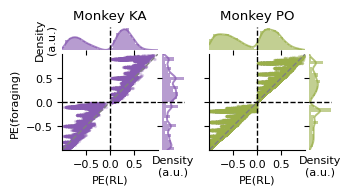

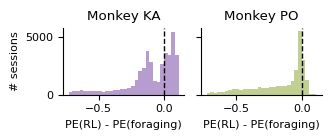

In [49]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

monkeys_in_data = sorted(neural_value_merged["monkey"].dropna().unique())
save_dir = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'figs', 'pred_error')
os.makedirs(save_dir, exist_ok=True)

# ---------- 1) 2D scatter with marginal distributions ----------
fig_scatter, axs_scatter = plt.subplots(
    1,
    len(monkeys_in_data),
    figsize=(2.8 * len(monkeys_in_data) *.8, 2.5*0.8),
    sharex=True,
    sharey=True,
)

if len(monkeys_in_data) == 1:
    axs_scatter = [axs_scatter]

lims = [
    min(neural_value_merged["PE_RL"].min(), neural_value_merged["PE_foraging"].min()),
    max(neural_value_merged["PE_RL"].max(), neural_value_merged["PE_foraging"].max()),
]

# Common bins for x and y marginals, shared across all monkey subplots
bins_xy = np.linspace(lims[0], lims[1], 31)

for i, (ax_main, monkey) in enumerate(zip(axs_scatter, monkeys_in_data)):
    behav_monkey = neural_value_merged[neural_value_merged["monkey"] == monkey]
    x = behav_monkey["PE_RL"].dropna()
    y = behav_monkey["PE_foraging"].dropna()
    hist_color = COLORS.get(monkey, "grey")

    # Main scatter
    ax_main.scatter(
        behav_monkey["PE_RL"],
        behav_monkey["PE_foraging"],
        alpha=0.1,
        s=2,
        color=hist_color,
    )
    ax_main.plot(lims, lims, "grey", linestyle="--", lw=1)
    ax_main.axhline(0, color="black", linestyle="dashed", linewidth=1)
    ax_main.axvline(0, color="black", linestyle="dashed", linewidth=1)
    ax_main.set_xlim(lims)
    ax_main.set_ylim(lims)
    ax_main.set_aspect("equal", adjustable="box")
    ax_main.set_title(f"Monkey {str(monkey).upper()}")
    ax_main.set_xlabel("PE(RL)")
    sns.despine(ax=ax_main)

    # Marginals: top (x) and right (y)
    divider = make_axes_locatable(ax_main)
    ax_x = divider.append_axes("top", size="24%", pad=0.04, sharex=ax_main)
    ax_y = divider.append_axes("right", size="24%", pad=0.04, sharey=ax_main)
    ax_x.set_title(f"Monkey {str(monkey).upper()}")

    ax_x.hist(
        x,
        bins=bins_xy,
        density=True,
        alpha=0.6,
        color=hist_color,
        edgecolor="none",
    )
    if len(x) > 1 and x.nunique() > 1:
        sns.kdeplot(x=x, ax=ax_x, color=hist_color, alpha=0.75, linewidth=1.4, clip=lims)

    ax_y.hist(
        y,
        bins=bins_xy,
        density=True,
        orientation="horizontal",
        alpha=0.6,
        color=hist_color,
        edgecolor="none",
    )
    if len(y) > 1 and y.nunique() > 1:
        sns.kdeplot(y=y, ax=ax_y, color=hist_color, alpha=0.75, linewidth=1.4, clip=lims)

    ax_x.axvline(0, color="black", linestyle="dashed", linewidth=1)
    ax_y.axhline(0, color="black", linestyle="dashed", linewidth=1)

    # Remove PE labels on marginals; keep density text and hide density axis ticks
    ax_x.set_xlabel("")
    ax_y.set_ylabel("")
    if i == 0:
        ax_x.set_ylabel("Density\n(a.u.)", fontsize=8, ha="center")
    else:
        ax_x.set_ylabel("")
    ax_y.set_xlabel("Density\n(a.u.)", fontsize=8, ha="center")

    ax_x.tick_params(axis="x", labelbottom=False)
    ax_x.tick_params(axis="y", left=False, labelleft=False)
    ax_y.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_y.tick_params(axis="y", labelleft=False)

    ax_x.set_xlim(lims)
    ax_y.set_ylim(lims)
    sns.despine(ax=ax_x, left=True, bottom=True)
    sns.despine(ax=ax_y, left=True, bottom=True)

axs_scatter[0].set_ylabel("PE(foraging)")
fig_scatter.tight_layout()
fig_scatter.subplots_adjust(wspace=-0.35)
fig_scatter.savefig(
    os.path.join(save_dir, "pe_scatter_with_marginals.png"),
    format="png",
    dpi=300,
    #transparent=True,
    bbox_inches="tight",
)
plt.show()

# ---------- 2) Distribution of PE1 - PE2 (PE_RL - PE_foraging) ----------
fig_hist, axs_hist = plt.subplots(
    1,
    len(monkeys_in_data),
    figsize=(2.1 * len(monkeys_in_data)*.8, 1.8*0.8),
    sharex=True,
    sharey=True,
)

if len(monkeys_in_data) == 1:
    axs_hist = [axs_hist]

pe_diff = neural_value_merged["PE_RL"] - neural_value_merged["PE_foraging"]

# Use common bins across monkeys for direct comparison
x_min, x_max = np.nanpercentile(pe_diff, [1, 99])
bins = np.linspace(x_min, x_max, 31)

for ax, monkey in zip(axs_hist, monkeys_in_data):
    behav_monkey = neural_value_merged[neural_value_merged["monkey"] == monkey]
    pe_diff_monkey = behav_monkey["PE_RL"] - behav_monkey["PE_foraging"]
    pe_diff_monkey = pe_diff_monkey.dropna()

    ax.hist(
        pe_diff_monkey,
        bins=bins,
        density=False,
        alpha=0.6,
        color=COLORS.get(monkey, "grey"),
        edgecolor="none",
    )
    ax.axvline(0, color="black", linestyle="dashed", linewidth=1)
    ax.set_title(f"Monkey {str(monkey).upper()}")
    ax.set_xlabel("PE(RL) - PE(foraging)")
    sns.despine(ax=ax)

axs_hist[0].set_ylabel("# sessions")
fig_hist.tight_layout()
fig_hist.savefig(
    os.path.join(save_dir, "pe_diff_histogram.svg"),
    format="svg",
    dpi=300,
    transparent=True,
    bbox_inches="tight",
)

PE_RL_z fit: n=386, slope=0.3014, intercept=-0.0039, r=0.5243, R2=0.2749, p=1.218e-28
PE_foraging_z fit: n=386, slope=0.3439, intercept=-0.0040, r=0.5957, R2=0.3549, p=1.907e-38


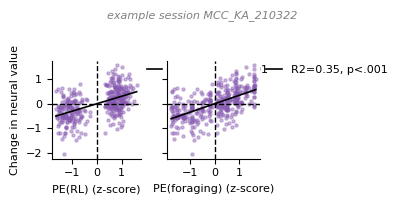

,monkey,session,subregion,trial_id,PE_RL_z,PE_foraging_z,dV
27759,ka,210322,MCC,8,-0.863141,-0.208796,-0.306960
27760,ka,210322,MCC,9,0.687848,1.581780,0.272865
27761,ka,210322,MCC,10,0.570532,0.880722,0.260650
27762,ka,210322,MCC,11,0.483224,0.488107,0.476514
27763,ka,210322,MCC,12,0.418250,0.268231,0.741082


In [58]:
from scipy.stats import linregress

example = neural_value_merged.copy()
save_dir = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'figs', 'pred_error')
os.makedirs(save_dir, exist_ok=True)

example = example[
    (example["subregion"].astype(str).str.upper() == "MCC")
    & (example["session"].astype(str).str.upper() == "210322")
].sort_values("trial_id")


def zscore_series(series):
    std = series.std(ddof=0)
    if pd.isna(std) or np.isclose(std, 0):
        return pd.Series(np.nan, index=series.index)
    return (series - series.mean()) / std


example["PE_RL_z"] = zscore_series(example["PE_RL"])
example["PE_foraging_z"] = zscore_series(example["PE_foraging"])

fig, axes = plt.subplots(1, 2, figsize=(2.8 * 2 * 0.8, 2.5 * 0.8), sharey=True)

plot_specs = [
    ("PE_RL_z", "PE(RL) (z-score)"),
    ("PE_foraging_z", "PE(foraging) (z-score)"),
]

for ax, (x_col, x_label) in zip(axes, plot_specs):
    data = example[[x_col, "dV"]].dropna()

    ax.scatter(
        data[x_col],
        data["dV"],
        s=5,
        alpha=0.4,
        color=COLORS.get("ka", "grey"),
    )

    if len(data) >= 2 and data[x_col].nunique() > 1:
        fit = linregress(data[x_col], data["dV"])
        slope = fit.slope
        intercept = fit.intercept
        r = fit.rvalue
        r2 = r ** 2
        p_value = fit.pvalue

        x_fit = np.linspace(data[x_col].min(), data[x_col].max(), 100)
        y_fit = slope * x_fit + intercept
        ax.plot(
            x_fit,
            y_fit,
            color="black",
            linewidth=1.2,
            label=f"R2={r2:.2f}, p<.001",
        )

        print(
            f"{x_col} fit: n={len(data)}, slope={slope:.4f}, intercept={intercept:.4f}, "
            f"r={r:.4f}, R2={r2:.4f}, p={p_value:.3e}"
        )
        ax.legend(
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            frameon=False,
            fontsize=8,
            borderaxespad=0.0,
            handlelength=1.4,
        )
    else:
        print(f"{x_col} fit: not enough non-constant data to fit.")

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel(x_label, fontsize=8)
    ax.tick_params(axis="both", labelsize=8)
    ax.set_aspect("equal", adjustable="box")
    sns.despine(ax=ax)

axes[0].set_ylabel("Change in neural value", fontsize=8)
fig.suptitle("example session MCC_KA_210322", fontstyle="italic", color="grey", fontsize=8)
fig.tight_layout(rect=[0, 0, 1, 0.9])
fig.subplots_adjust(wspace=-0.2)
fig.savefig(
    os.path.join(save_dir, "example_session_MCC_KA_210322.svg"),
    format="svg",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

example[["monkey", "session", "subregion", "trial_id", "PE_RL_z", "PE_foraging_z", "dV"]].head()

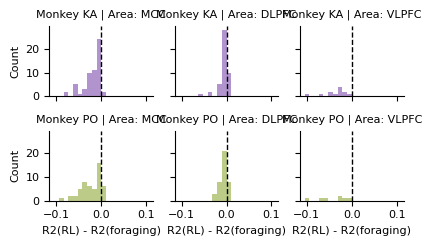

,monkey,session,subregion,n_RL,RL_r2,RL_p,n_foraging,foraging_r2,foraging_p,r2_diff
0,ka,010720,MCC,419,0.137001,4.732473e-15,419,0.191003,5.671548e-21,-0.054002
1,ka,010720,vLPFC,419,0.001888,3.750158e-01,419,0.005766,1.206727e-01,-0.003878
2,ka,010822,MCC,331,0.036923,4.388591e-04,331,0.039013,2.996783e-04,-0.002089
3,ka,010822,dLPFC,331,0.033660,7.971535e-04,331,0.031452,1.195015e-03,0.002208
4,ka,010922,MCC,196,0.031052,1.348814e-02,196,0.028934,1.714606e-02,0.002118


In [68]:
from scipy.stats import linregress


def zscore_series(series):
    std = series.std(ddof=0)
    if pd.isna(std) or np.isclose(std, 0):
        return pd.Series(np.nan, index=series.index)
    return (series - series.mean()) / std


def fit_stats(x, y):
    data = pd.concat([x, y], axis=1).dropna()
    x_valid = data.iloc[:, 0]
    y_valid = data.iloc[:, 1]

    if len(data) < 3 or x_valid.nunique() < 2 or y_valid.nunique() < 2:
        return {
            "n": len(data),
            "slope": np.nan,
            "intercept": np.nan,
            "r": np.nan,
            "r2": np.nan,
            "p": np.nan,
        }

    fit = linregress(x_valid, y_valid)
    return {
        "n": len(data),
        "slope": fit.slope,
        "intercept": fit.intercept,
        "r": fit.rvalue,
        "r2": fit.rvalue ** 2,
        "p": fit.pvalue,
    }


records = []
group_cols = ["monkey", "session", "subregion"]

for (monkey, session, subregion), grp in neural_value_merged.groupby(group_cols):
    grp = grp.copy()
    grp["PE_RL_z"] = zscore_series(grp["PE_RL"])
    grp["PE_foraging_z"] = zscore_series(grp["PE_foraging"])

    rl_fit = fit_stats(grp["PE_RL_z"], grp["dV"])
    foraging_fit = fit_stats(grp["PE_foraging_z"], grp["dV"])

    records.append(
        {
            "monkey": monkey,
            "session": session,
            "subregion": subregion,
            "n_RL": rl_fit["n"],
            "RL_r2": rl_fit["r2"],
            "RL_p": rl_fit["p"],
            "n_foraging": foraging_fit["n"],
            "foraging_r2": foraging_fit["r2"],
            "foraging_p": foraging_fit["p"],
            "r2_diff": rl_fit["r2"] - foraging_fit["r2"],
        }
    )

fit_results = pd.DataFrame(records).sort_values(group_cols).reset_index(drop=True)

monkeys = sorted(fit_results["monkey"].dropna().unique())
subregions = sorted(fit_results["subregion"].dropna().unique())
save_dir = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'figs', 'pred_error')
os.makedirs(save_dir, exist_ok=True)

fig, axes = plt.subplots(
    len(monkeys),
    len(subregions),
    figsize=(2.8 * len(subregions) * 0.5, 2.5 * len(monkeys) * 0.5),
    sharex=True,
    sharey=True,
)

if len(monkeys) == 1 and len(subregions) == 1:
    axes = np.array([[axes]])
elif len(monkeys) == 1:
    axes = np.array([axes])
elif len(subregions) == 1:
    axes = np.array([[ax] for ax in axes])

# Common bins centered around 0 for direct cross-panel comparison
diff_all = fit_results["r2_diff"].dropna()
if len(diff_all) > 0:
    max_abs = np.nanmax(np.abs(diff_all))
    max_abs = max(max_abs, 0.05)
else:
    max_abs = 0.05
bins_diff = np.linspace(-max_abs, max_abs, 21)

for i, monkey in enumerate(monkeys):
    for j, subregion in enumerate(subregions):
        ax = axes[i, j]
        panel = fit_results[(fit_results["monkey"] == monkey) & (fit_results["subregion"] == subregion)]

        r2_diff_vals = panel["r2_diff"].dropna()
        ax.hist(
            r2_diff_vals,
            bins=bins_diff,
            alpha=0.65,
            color=COLORS.get(str(monkey).lower(), "grey"),
            edgecolor="none",
        )

        ax.axvline(0, color="black", linestyle="dashed", linewidth=1)
        ax.set_title(f"Monkey {str(monkey).upper()} | Area: {str(subregion).upper()}", fontsize=8)
        ax.tick_params(axis="both", labelsize=8)
        sns.despine(ax=ax)

        if i == len(monkeys) - 1:
            ax.set_xlabel("R2(RL) - R2(foraging)", fontsize=8)
        if j == 0:
            ax.set_ylabel("Count", fontsize=8)

fig.tight_layout()
fig.savefig(
    os.path.join(save_dir, "r2_diff_histogram_by_monkey_area.svg"),
    format="svg",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

fit_results.head()